# Week 9 — LAB 1: Difference Mapping 差異製圖
## 依照 0421 簡報規格實作

**對應簡報**：`遙測與空間資訊之分析與應用-0421.pdf`, Slide 9 (LAB 1, 35 min)

---

### 🎯 本 Lab 目標 (4 Steps)

| # | Step | 對應簡報頁 |
|---|---|---|
| 1 | Compute NDVI, NDWI for three dates | Slide 5, 6 |
| 2 | Generate difference maps ΔNDVI, ΔNDWI | Slide 7 |
| 3 | **Sweep thresholds −0.10 to −0.50** (for ΔNDVI < t, 偵測崩塌/植被消失) | Slide 8 |
| 4 | Select best threshold and justify | Slide 8 |

### 📍 個案
**Matai'an Barrier Lake (馬太鞍堰塞湖) — 2025 Typhoon Colo**
- Pre : 颱風前基準 (2025-06-01)
- Mid : 災中 — 堰塞湖 + 崩塌最大範圍 (2025-08-15)
- Post: 恢復期 — 湖水排空 (2025-10-10)

### 🧭 兩個方向的變遷偵測 (簡報 Slide 7)

| 現象 | 指標方向 | 語意 |
|---|---|---|
| **植被消失 / 崩塌** | ΔNDVI **< threshold** (threshold 負值) | 本 Lab 主軸 — slide 8 的臨界值範圍 |
| **水體出現 / 堰塞** | ΔNDWI **> threshold** (threshold 正值) | 對稱雙向，順便一起做 |


In [1]:
# [L1-S1] Environment Setup / 環境初始化
# ──────────────────────────────────────────────────────────────────
# 【中文說明】
# 匯入套件、設定 CJK 中文字型 (避免圖片中文變豆腐字)。
# 字型設定必須放在 plt.style.use 之後，否則會被 style 重置。
# ──────────────────────────────────────────────────────────────────

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 研究區域 (馬太鞍流域外接矩形)
BBOX = [121.28, 23.56, 121.52, 23.76]   # [W, S, E, N]
LAKE_BBOX = [121.27, 23.68, 121.32, 23.72]
SCENE_DATES = {'Pre': '2025-06-01', 'Mid': '2025-08-15', 'Post': '2025-10-10'}

# SCL 晴空類別
SCL_CLEAR_CLASSES = [2, 4, 5, 6, 7, 11]
def scl_to_clear(scl): return np.isin(scl, SCL_CLEAR_CLASSES)

OUTPUT_DIR = 'output_lab1_pdf'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 先設 style，再覆蓋中文字型
plt.style.use('seaborn-v0_8-darkgrid')
from matplotlib import font_manager, rcParams
_prefer = ['PingFang HK', 'Heiti TC', 'Songti SC', 'Hiragino Sans GB', 'STHeiti', 'Arial Unicode MS']
_avail = {f.name for f in font_manager.fontManager.ttflist}
_font = next((n for n in _prefer if n in _avail), None)
if _font:
    rcParams['font.sans-serif'] = [_font] + [x for x in rcParams.get('font.sans-serif', []) if x != _font]
    rcParams['font.family'] = 'sans-serif'
    rcParams['axes.unicode_minus'] = False

print(f'✓ Setup complete / 環境設定完成')
print(f'  Output dir: {OUTPUT_DIR}')
print(f'  CJK font:   {_font}')
print(f'  Study BBOX: {BBOX}')
print(f'  Dates:      {SCENE_DATES}')

✓ Setup complete / 環境設定完成
  Output dir: output_lab1_pdf
  CJK font:   PingFang HK
  Study BBOX: [121.28, 23.56, 121.52, 23.76]
  Dates:      {'Pre': '2025-06-01', 'Mid': '2025-08-15', 'Post': '2025-10-10'}


In [2]:
# [L1-S2] Synthetic Sentinel-2 Data Generator / 合成三幕 S-2 資料
# ──────────────────────────────────────────────────────────────────
# 【中文說明】
# 由於 STAC 連線速度受網路影響，教學用合成資料 (deterministic seed) 重現。
#   1. 建立 (H=200, W=240) 的 ~100 m 粗格網覆蓋 BBOX (~24.4 × 22.2 km, ~543 km²)。
#   2. 依「三幕劇情」放入 veg/water/landslide/bare 類別 → 映射 S-2 反射率。
#   3. 加入 SCL 雲 (災中最多，颱風季特徵)。
# ⚠ 注意：~100 m 粗格僅為教學示範；真實 Sentinel-2 L2A 為 10 m (VNIR) / 20 m (SWIR)。
# ──────────────────────────────────────────────────────────────────

BANDS = ['B02', 'B03', 'B04', 'B08', 'B11']
# Sentinel-2 反射率特徵 (typical, 0-1 scaled)
SIGS = {
    'veg':       np.array([0.04, 0.08, 0.05, 0.35, 0.20]),  # 健康植被 (NIR 高)
    'water':     np.array([0.08, 0.10, 0.06, 0.02, 0.01]),  # 水體 (NIR 很低)
    'bare':      np.array([0.15, 0.20, 0.25, 0.30, 0.40]),
    'landslide': np.array([0.18, 0.22, 0.28, 0.22, 0.38]),  # 崩塌 (裸土+岩石)
    'cloud':     np.array([0.80, 0.82, 0.83, 0.85, 0.70]),
}

H, W = 200, 240
lon_min, lat_min, lon_max, lat_max = BBOX
PIX_W = (lon_max - lon_min) / W
PIX_H = (lat_max - lat_min) / H
GEOT = (lon_min, PIX_W, 0.0, lat_max, 0.0, -PIX_H)

def _disk(shape, c, r):
    rr, cc = np.ogrid[:shape[0], :shape[1]]
    return (rr - c[0])**2 + (cc - c[1])**2 <= r**2

def class_map(scene):
    """每幕的地物類別圖 (deterministic)."""
    cls = np.full((H, W), 'veg', dtype='<U10')
    cls[120:135, 180:195] = 'bare'; cls[160:175, 60:80] = 'bare'
    if scene in ('Mid', 'Post'):
        cls[35:50, 155:180] = 'landslide'
        cls[45:60, 115:140] = 'landslide'
        cls[60:78, 75:100]  = 'landslide'
        cls[85:100, 5:30]   = 'landslide'
        cls[105:125, 140:165] = 'landslide'
    if scene == 'Mid':
        cls[_disk((H, W), (62, 12), 13)] = 'water'
    if scene == 'Post':
        cls[_disk((H, W), (62, 12), 4)] = 'water'
    return cls

def cloud_scl(scene):
    rng = np.random.default_rng({'Pre': 101, 'Mid': 202, 'Post': 303}[scene])
    scl = np.full((H, W), 4, dtype=np.int16)  # 預設 vegetation
    cfg = {'Pre': (3, (5, 12)), 'Mid': (8, (10, 25)), 'Post': (4, (6, 15))}[scene]
    for _ in range(cfg[0]):
        c = (rng.integers(0, H), rng.integers(0, W))
        scl[_disk((H, W), c, rng.integers(*cfg[1]))] = 9  # 雲
    if scene == 'Mid':
        b = rng.integers(0, H - 10)
        scl[b:b+6, :] = np.where(rng.random((6, W)) < 0.4, 10, scl[b:b+6, :])
    return scl

def make_cube(scene):
    rng = np.random.default_rng({'Pre': 113, 'Mid': 226, 'Post': 339}[scene])
    cm = class_map(scene); scl = cloud_scl(scene)
    cube = np.zeros((H, W, 5), dtype=np.float32)
    for name, sig in SIGS.items():
        if name == 'cloud': continue
        m = (cm == name)
        if m.any():
            noise = rng.normal(0, 0.012, (m.sum(), 5)).astype(np.float32)
            cube[m] = sig + noise
    cloudy = np.isin(scl, [8, 9, 10])
    cube[cloudy] = SIGS['cloud'] + rng.normal(0, 0.02, (cloudy.sum(), 5))
    return np.clip(cube, 0, 1), scl

scenes = {}
for s in ('Pre', 'Mid', 'Post'):
    cube, scl = make_cube(s)
    scenes[s] = {'cube': cube, 'scl': scl, 'clear': scl_to_clear(scl)}
    print(f'  {s}: shape={cube.shape}, clear-sky={scenes[s]["clear"].mean():.1%}')
print('✓ Three-act cubes generated / 三幕立方體完成')

  Pre: shape=(200, 240, 5), clear-sky=98.3%
  Mid: shape=(200, 240, 5), clear-sky=86.1%
  Post: shape=(200, 240, 5), clear-sky=96.6%
✓ Three-act cubes generated / 三幕立方體完成


In [3]:
# [L1-S3] Compute NDVI & NDWI for 3 Dates / 計算 NDVI 與 NDWI (Step 1)
# ──────────────────────────────────────────────────────────────────
# 【中文說明】
# 依照 Slide 5、Slide 6 的公式：
#   NDVI = (NIR − Red)  / (NIR + Red)    [B08, B04]
#   NDWI = (Green − NIR)/ (Green + NIR)  [B03, B08]
# 兩個指標皆範圍 [-1, +1]；NDVI↑ = 植被濃、NDWI↑ = 水體多。
# ──────────────────────────────────────────────────────────────────

def ndvi(cube):  # NIR=B08(idx 3), Red=B04(idx 2)
    nir, red = cube[..., 3], cube[..., 2]
    return (nir - red) / (nir + red + 1e-9)

def ndwi(cube):  # Green=B03(idx 1), NIR=B08(idx 3)
    g, n = cube[..., 1], cube[..., 3]
    return (g - n) / (g + n + 1e-9)

idx = {}
for s in scenes:
    c = scenes[s]['cube']
    idx[s] = {'NDVI': ndvi(c), 'NDWI': ndwi(c)}
    # 套雲遮罩：雲像素設 NaN，後續計算自動忽略
    cm = ~scenes[s]['clear']
    idx[s]['NDVI'][cm] = np.nan
    idx[s]['NDWI'][cm] = np.nan

print('場景級均值 (只算晴空像素)：')
print(f"{'Scene':>6} | {'NDVI':>8} | {'NDWI':>8}")
for s in ('Pre', 'Mid', 'Post'):
    print(f"{s:>6} | {np.nanmean(idx[s]['NDVI']):>+8.3f} | {np.nanmean(idx[s]['NDWI']):>+8.3f}")
print('\n✓ NDVI / NDWI computed for 3 dates')

場景級均值 (只算晴空像素)：
 Scene |     NDVI |     NDWI
   Pre |   +0.744 |   -0.624
   Mid |   +0.700 |   -0.587
  Post |   +0.704 |   -0.595

✓ NDVI / NDWI computed for 3 dates


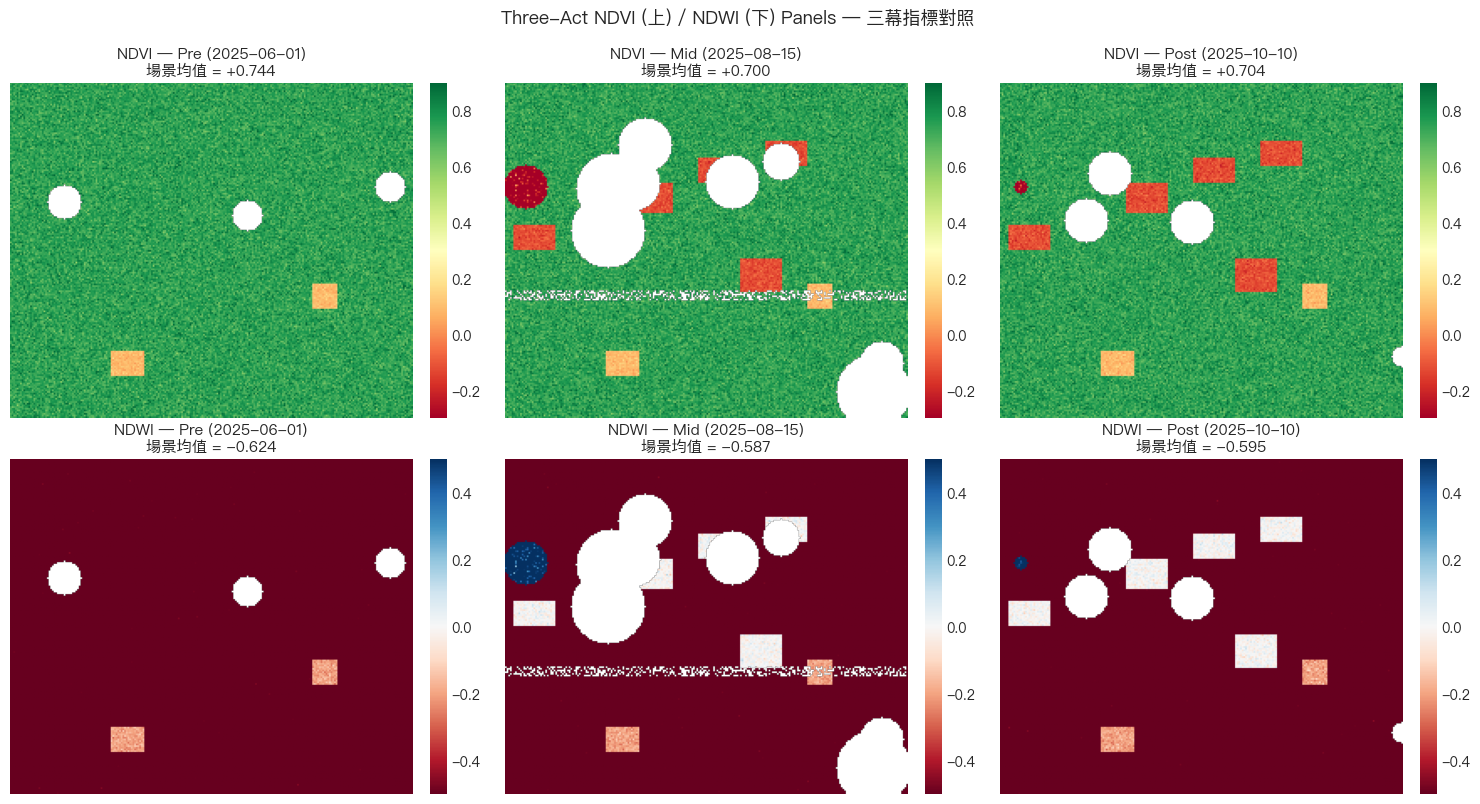

✓ Saved: output_lab1_pdf/PDF_Lab1_NDVI_NDWI_3act.png


In [4]:
# [L1-S4] Visualize Three-Act NDVI & NDWI Panels / 視覺化三幕 2×3 指標圖
# ──────────────────────────────────────────────────────────────────
# 【中文說明】
# 2×3 面板 — 上排 NDVI、下排 NDWI；左→右 = Pre/Mid/Post。
# 對應 Slide 5 (NDVI Pulse of the Forest) + Slide 6 (NDWI Mapping the Flood Extent)。
# 觀察重點：
#   - Pre  NDVI ≈ 0.7 (健康植被)  → Mid NDVI 在湖/崩塌區大幅下降
#   - Pre  NDWI < 0 (陸地)         → Mid NDWI 在湖區變正 (水體出現)
# ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for j, s in enumerate(('Pre', 'Mid', 'Post')):
    # NDVI
    im0 = axes[0, j].imshow(idx[s]['NDVI'], cmap='RdYlGn', vmin=-0.3, vmax=0.9)
    axes[0, j].set_title(f'NDVI — {s} ({SCENE_DATES[s]})\n'
                         f'場景均值 = {np.nanmean(idx[s]["NDVI"]):+.3f}', fontsize=11)
    axes[0, j].axis('off')
    plt.colorbar(im0, ax=axes[0, j], fraction=0.046, pad=0.04)
    # NDWI
    im1 = axes[1, j].imshow(idx[s]['NDWI'], cmap='RdBu', vmin=-0.5, vmax=0.5)
    axes[1, j].set_title(f'NDWI — {s} ({SCENE_DATES[s]})\n'
                         f'場景均值 = {np.nanmean(idx[s]["NDWI"]):+.3f}', fontsize=11)
    axes[1, j].axis('off')
    plt.colorbar(im1, ax=axes[1, j], fraction=0.046, pad=0.04)

fig.suptitle('Three-Act NDVI (上) / NDWI (下) Panels — 三幕指標對照',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/PDF_Lab1_NDVI_NDWI_3act.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {OUTPUT_DIR}/PDF_Lab1_NDVI_NDWI_3act.png')

三幕交集晴空像素比例：83.2%


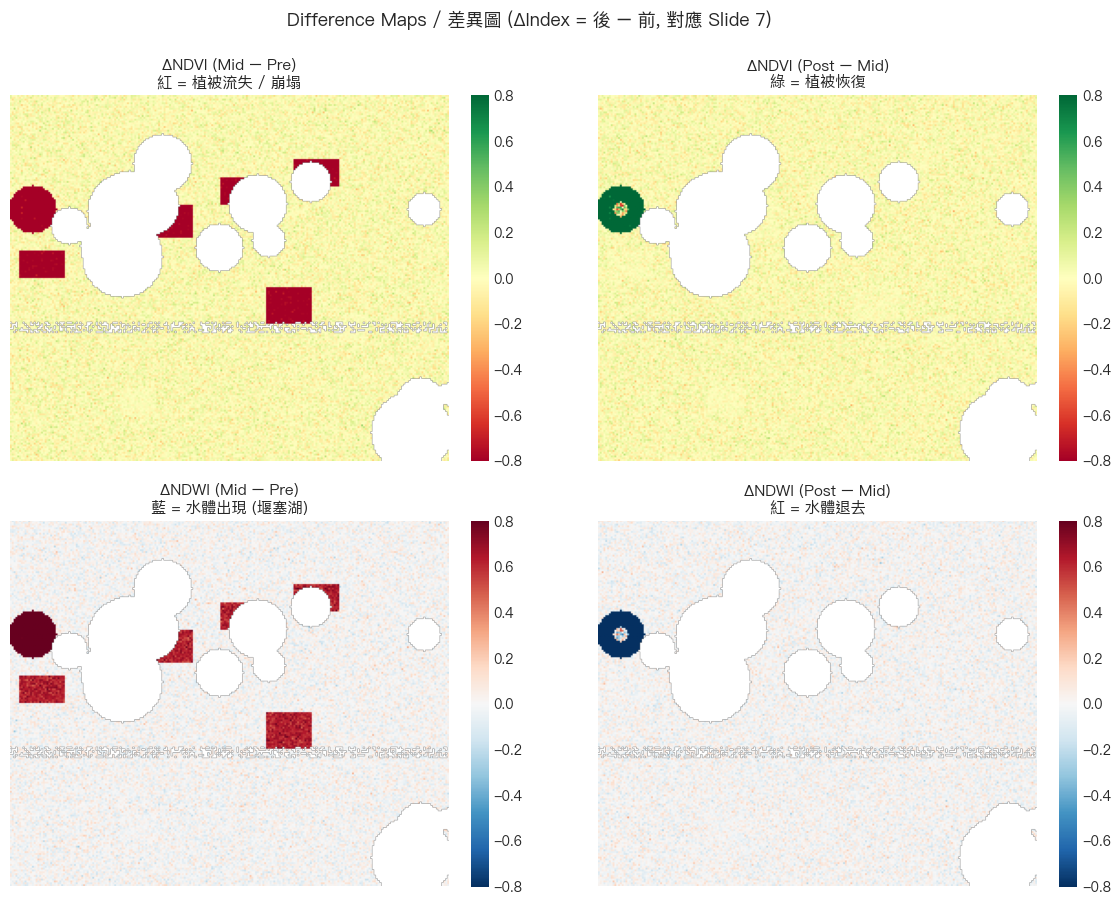


✓ Difference maps saved: output_lab1_pdf/PDF_Lab1_difference_maps.png

ΔIndex 全場景均值 (只算三幕交集晴空)：
    ΔIndex |    Mid-Pre |   Post-Mid
     ΔNDVI |    -0.0444 |    +0.0146
     ΔNDWI |    +0.0376 |    -0.0155


In [5]:
# [L1-S5] Build Difference Maps ΔNDVI, ΔNDWI / 建立差異圖 (Step 2)
# ──────────────────────────────────────────────────────────────────
# 【中文說明】 (對應 Slide 7, ΔIndex = Index_post − Index_pre)
# 我們做兩段時間的差異：
#   Mid − Pre  → 災中相對基準，出現了湖水/崩塌
#   Post − Mid → 災後相對災中，水退去/植被部分恢復
# 差異圖同樣套三幕交集雲遮罩 (Pre & Mid & Post 皆晴空像素)。
# ──────────────────────────────────────────────────────────────────

valid = scenes['Pre']['clear'] & scenes['Mid']['clear'] & scenes['Post']['clear']
print(f'三幕交集晴空像素比例：{valid.mean():.1%}')

d_ndvi = {
    'Mid-Pre':  np.where(valid, idx['Mid']['NDVI']  - idx['Pre']['NDVI'],  np.nan),
    'Post-Mid': np.where(valid, idx['Post']['NDVI'] - idx['Mid']['NDVI'],  np.nan),
}
d_ndwi = {
    'Mid-Pre':  np.where(valid, idx['Mid']['NDWI']  - idx['Pre']['NDWI'],  np.nan),
    'Post-Mid': np.where(valid, idx['Post']['NDWI'] - idx['Mid']['NDWI'],  np.nan),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
titles = {
    (0, 0): ('ΔNDVI (Mid − Pre)\n紅 = 植被流失 / 崩塌', d_ndvi['Mid-Pre']),
    (0, 1): ('ΔNDVI (Post − Mid)\n綠 = 植被恢復', d_ndvi['Post-Mid']),
    (1, 0): ('ΔNDWI (Mid − Pre)\n藍 = 水體出現 (堰塞湖)', d_ndwi['Mid-Pre']),
    (1, 1): ('ΔNDWI (Post − Mid)\n紅 = 水體退去', d_ndwi['Post-Mid']),
}
for (r, c), (title, arr) in titles.items():
    cmap = 'RdYlGn' if 'NDVI' in title else 'RdBu_r'
    im = axes[r, c].imshow(arr, cmap=cmap, vmin=-0.8, vmax=0.8)
    axes[r, c].set_title(title, fontsize=11)
    axes[r, c].axis('off')
    plt.colorbar(im, ax=axes[r, c], fraction=0.046, pad=0.04)

fig.suptitle('Difference Maps / 差異圖 (ΔIndex = 後 − 前, 對應 Slide 7)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/PDF_Lab1_difference_maps.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✓ Difference maps saved: {OUTPUT_DIR}/PDF_Lab1_difference_maps.png')
print('\nΔIndex 全場景均值 (只算三幕交集晴空)：')
print(f"{'ΔIndex':>10} | {'Mid-Pre':>10} | {'Post-Mid':>10}")
print(f"{'ΔNDVI':>10} | {np.nanmean(d_ndvi['Mid-Pre']):>+10.4f} | {np.nanmean(d_ndvi['Post-Mid']):>+10.4f}")
print(f"{'ΔNDWI':>10} | {np.nanmean(d_ndwi['Mid-Pre']):>+10.4f} | {np.nanmean(d_ndwi['Post-Mid']):>+10.4f}")

### 📖 Step 2 小結 (簡報 Slide 7 的判讀邏輯)

| 變化類型 | 指標方向 | 判讀規則 |
|---|---|---|
| **植被消失 (崩塌)** | ΔNDVI **負值越大** | `ΔNDVI < threshold` (threshold 取負值，例如 −0.20) |
| **水體出現 (堰塞)** | ΔNDWI **正值越大** | `ΔNDWI > threshold` (threshold 取正值，例如 +0.15) |

**💡 為何簡報 Lab 1 用負值臨界值 (−0.10 到 −0.50)？**

> Slide 8 的範例 (`−0.10` 寬鬆 / `−0.55` 嚴格) 是在偵測「植被消失」— 因此用的是 **ΔNDVI < threshold**。臨界值絕對值越大 = 要求變化越劇烈 → 判定結果越嚴格。

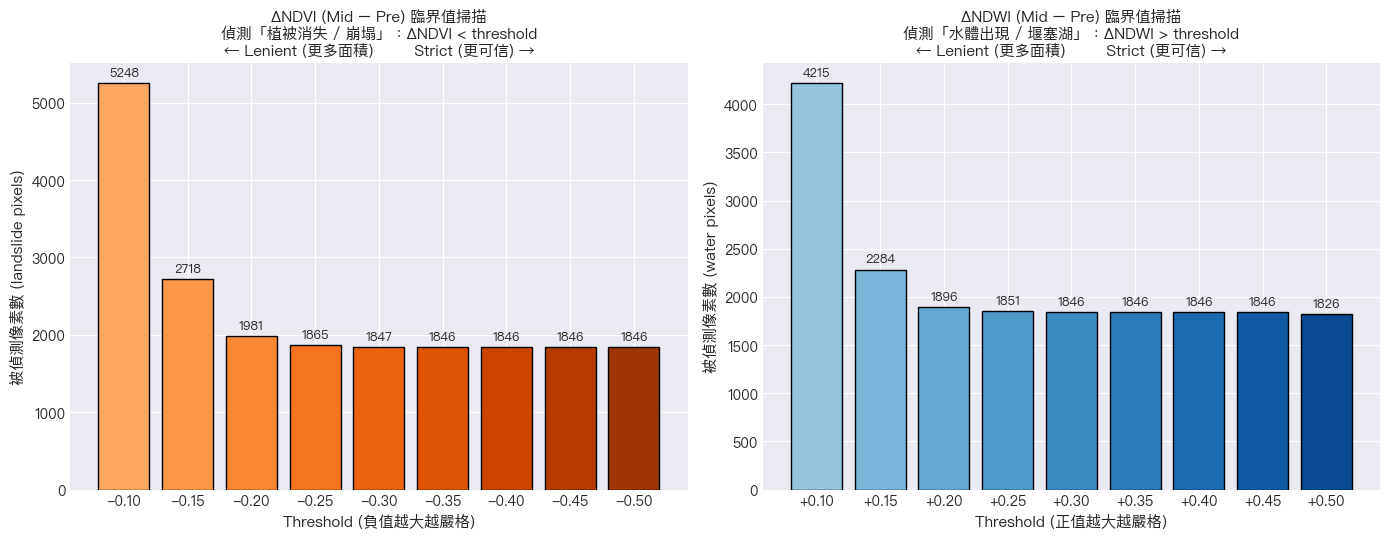


▸ ΔNDVI 掃描 (landslide detection)：
 threshold |  detected px |   area (km², ~100m/px)
     -0.10 |         5248 |                  52.48
     -0.15 |         2718 |                  27.18
     -0.20 |         1981 |                  19.81
     -0.25 |         1865 |                  18.65
     -0.30 |         1847 |                  18.47
     -0.35 |         1846 |                  18.46
     -0.40 |         1846 |                  18.46
     -0.45 |         1846 |                  18.46
     -0.50 |         1846 |                  18.46

▸ ΔNDWI 掃描 (water detection)：
 threshold |  detected px |   area (km², ~100m/px)
     +0.10 |         4215 |                  42.15
     +0.15 |         2284 |                  22.84
     +0.20 |         1896 |                  18.96
     +0.25 |         1851 |                  18.51
     +0.30 |         1846 |                  18.46
     +0.35 |         1846 |                  18.46
     +0.40 |         1846 |                  18.46
     +0.45 |    

In [6]:
# [L1-S6] Threshold Sensitivity Sweep / 臨界值敏感度掃描 (Step 3)
# ──────────────────────────────────────────────────────────────────
# 【中文說明】 對應 Slide 8 "The Commander's Cut"
#   ➊ ΔNDVI (Mid−Pre) 掃描：threshold = −0.10 → −0.50，判 ΔNDVI < threshold 為「崩塌」
#   ➋ ΔNDWI (Mid−Pre) 掃描：threshold = +0.10 → +0.50，判 ΔNDWI > threshold 為「水體」
#   兩組一起畫，展示「臨界值即決策，不是公式」的核心概念。
# ──────────────────────────────────────────────────────────────────

# (1) ΔNDVI 偵測崩塌 — threshold 由 lenient (−0.10) 到 strict (−0.50)
thr_ndvi = np.round(np.linspace(-0.10, -0.50, 9), 3)
area_ndvi = np.array([int(np.nansum(d_ndvi['Mid-Pre'] < t)) for t in thr_ndvi])

# (2) ΔNDWI 偵測水體 — threshold 由 lenient (+0.10) 到 strict (+0.50)
thr_ndwi = np.round(np.linspace(+0.10, +0.50, 9), 3)
area_ndwi = np.array([int(np.nansum(d_ndwi['Mid-Pre'] > t)) for t in thr_ndwi])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- 左：ΔNDVI (崩塌) ---
ax = axes[0]
colors_ndvi = plt.cm.Oranges(np.linspace(0.4, 0.9, len(thr_ndvi)))
bars = ax.bar([f'{t:+.2f}' for t in thr_ndvi], area_ndvi, color=colors_ndvi, edgecolor='k')
ax.set_title('ΔNDVI (Mid − Pre) 臨界值掃描\n'
             '偵測「植被消失 / 崩塌」：ΔNDVI < threshold\n'
             '← Lenient (更多面積)        Strict (更可信) →', fontsize=11)
ax.set_xlabel('Threshold (負值越大越嚴格)', fontsize=11)
ax.set_ylabel('被偵測像素數 (landslide pixels)', fontsize=11)
for b, v in zip(bars, area_ndvi):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(area_ndvi)*0.01,
            f'{v}', ha='center', va='bottom', fontsize=9)

# --- 右：ΔNDWI (水體) ---
ax = axes[1]
colors_ndwi = plt.cm.Blues(np.linspace(0.4, 0.9, len(thr_ndwi)))
bars = ax.bar([f'{t:+.2f}' for t in thr_ndwi], area_ndwi, color=colors_ndwi, edgecolor='k')
ax.set_title('ΔNDWI (Mid − Pre) 臨界值掃描\n'
             '偵測「水體出現 / 堰塞湖」：ΔNDWI > threshold\n'
             '← Lenient (更多面積)        Strict (更可信) →', fontsize=11)
ax.set_xlabel('Threshold (正值越大越嚴格)', fontsize=11)
ax.set_ylabel('被偵測像素數 (water pixels)', fontsize=11)
for b, v in zip(bars, area_ndwi):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(area_ndwi)*0.01,
            f'{v}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/PDF_Lab1_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# 印表格
print('\n▸ ΔNDVI 掃描 (landslide detection)：')
print(f"{'threshold':>10} | {'detected px':>12} | {'area (km², ~100m/px)':>22}")
for t, a in zip(thr_ndvi, area_ndvi):
    print(f"{t:>+10.2f} | {a:>12d} | {a*0.01:>22.2f}")
print('\n▸ ΔNDWI 掃描 (water detection)：')
print(f"{'threshold':>10} | {'detected px':>12} | {'area (km², ~100m/px)':>22}")
for t, a in zip(thr_ndwi, area_ndwi):
    print(f"{t:>+10.2f} | {a:>12d} | {a*0.01:>22.2f}")
print(f'\n✓ Threshold sweep saved: {OUTPUT_DIR}/PDF_Lab1_threshold_sweep.png')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.1250792].


各 use case 的臨界值選擇與結果：

Use Case                       |   ΔNDVI |   ΔNDWI |    崩塌 px |    水體 px
────────────────────────────────────────────────────────────────────────────────
Disaster Alert (災害預警)          |   -0.10 |   +0.10 |     5248 |     4215
   └─ 寬鬆：寧可多警報也不漏掉任何一處可能崩塌/堰塞
Insurance Payout (保險理賠)        |   -0.25 |   +0.20 |     1865 |     1896
   └─ 平衡：在誤報與漏報之間取均衡，避免過度賠付或拒賠
Scientific Archive (學術典藏)      |   -0.40 |   +0.35 |     1846 |     1846
   └─ 嚴格：只記錄強訊號，降低假陽性以提升資料庫純度


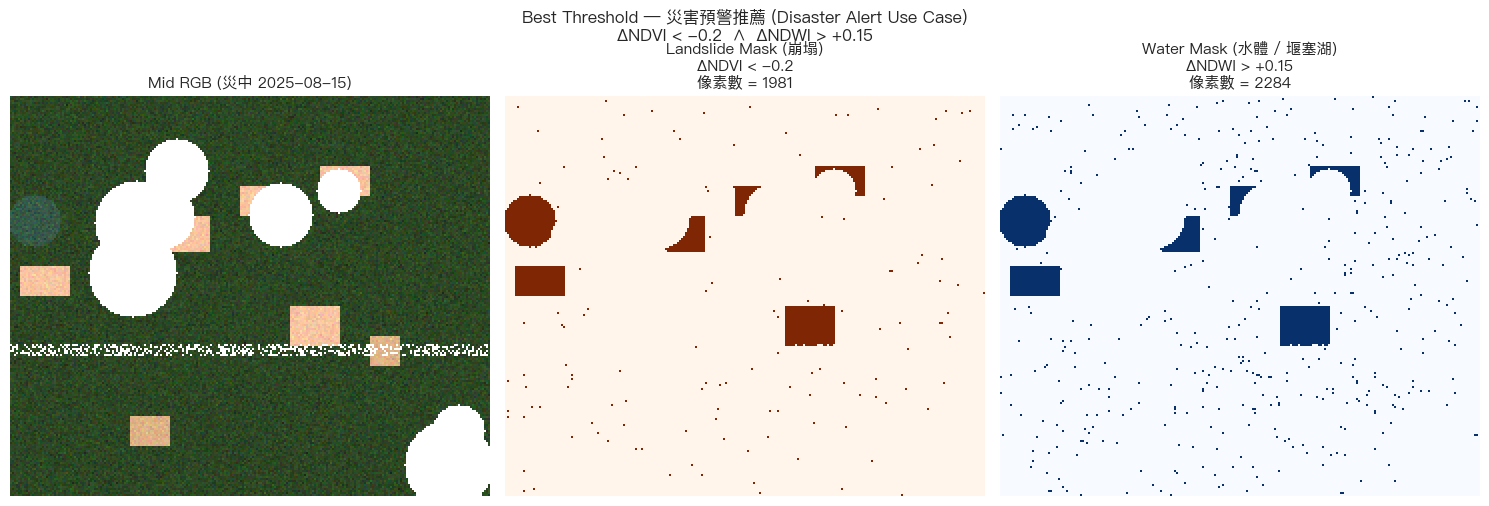


✓ Best threshold masks saved: output_lab1_pdf/PDF_Lab1_best_threshold_masks.png

推薦臨界值 (Disaster Alert)：
  ΔNDVI < -0.20  → 偵測 1981 px 崩塌
  ΔNDWI > +0.15  → 偵測 2284 px 水體


In [7]:
# [L1-S7] Select Best Threshold & Justify / 選擇最佳臨界值並說明 (Step 4)
# ──────────────────────────────────────────────────────────────────
# 【中文說明】
# 最佳臨界值「不是公式」 — 要依用途 (Disaster Alert / Insurance / Science) 決定。
# 以下用三個 use case 同時示範：
#   A. Disaster Alert  (災害預警) → 寬鬆，臨界值 |t| 小  → 高 Recall
#   B. Insurance Payout (保險理賠) → 平衡
#   C. Scientific Archive (科學典藏) → 嚴格，臨界值 |t| 大 → 高 Precision
# ──────────────────────────────────────────────────────────────────

USE_CASES = [
    ('Disaster Alert (災害預警)',   -0.10, +0.10, '寬鬆：寧可多警報也不漏掉任何一處可能崩塌/堰塞'),
    ('Insurance Payout (保險理賠)', -0.25, +0.20, '平衡：在誤報與漏報之間取均衡，避免過度賠付或拒賠'),
    ('Scientific Archive (學術典藏)', -0.40, +0.35, '嚴格：只記錄強訊號，降低假陽性以提升資料庫純度'),
]

print('各 use case 的臨界值選擇與結果：\n')
print(f"{'Use Case':<30} | {'ΔNDVI':>7} | {'ΔNDWI':>7} | {'崩塌 px':>8} | {'水體 px':>8}")
print('─' * 80)
for name, tv, tw, note in USE_CASES:
    a_v = int(np.nansum(d_ndvi['Mid-Pre'] < tv))
    a_w = int(np.nansum(d_ndwi['Mid-Pre'] > tw))
    print(f'{name:<30} | {tv:>+7.2f} | {tw:>+7.2f} | {a_v:>8d} | {a_w:>8d}')
    print(f'   └─ {note}')

# 以「災害預警」為本 Lab 推薦 — 產出最終偵測遮罩與疊圖
BEST_T_NDVI = -0.20    # 推薦臨界值
BEST_T_NDWI = +0.15

mask_landslide = (d_ndvi['Mid-Pre'] < BEST_T_NDVI).astype(np.uint8)
mask_water     = (d_ndwi['Mid-Pre'] > BEST_T_NDWI).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(scenes['Mid']['cube'][..., [2, 1, 0]] * 3.5, vmin=0, vmax=1)
axes[0].set_title(f'Mid RGB (災中 {SCENE_DATES["Mid"]})', fontsize=11)
axes[0].axis('off')

axes[1].imshow(mask_landslide, cmap='Oranges', vmin=0, vmax=1)
axes[1].set_title(f'Landslide Mask (崩塌)\nΔNDVI < {BEST_T_NDVI}\n'
                  f'像素數 = {mask_landslide.sum()}', fontsize=11)
axes[1].axis('off')

axes[2].imshow(mask_water, cmap='Blues', vmin=0, vmax=1)
axes[2].set_title(f'Water Mask (水體 / 堰塞湖)\nΔNDWI > +{BEST_T_NDWI}\n'
                  f'像素數 = {mask_water.sum()}', fontsize=11)
axes[2].axis('off')

fig.suptitle(f'Best Threshold — 災害預警推薦 (Disaster Alert Use Case)\n'
             f'ΔNDVI < {BEST_T_NDVI}  ∧  ΔNDWI > +{BEST_T_NDWI}',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/PDF_Lab1_best_threshold_masks.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✓ Best threshold masks saved: {OUTPUT_DIR}/PDF_Lab1_best_threshold_masks.png')
print(f'\n推薦臨界值 (Disaster Alert)：')
print(f'  ΔNDVI < {BEST_T_NDVI:+.2f}  → 偵測 {mask_landslide.sum()} px 崩塌')
print(f'  ΔNDWI > {BEST_T_NDWI:+.2f}  → 偵測 {mask_water.sum()} px 水體')

## ✅ Lab 1 結論 & 簡短中文問答

### 四步驟完成檢核

| Step | 產出 | 檔案 |
|---|---|---|
| 1. Compute NDVI/NDWI × 3 dates | 2×3 指標面板 | `PDF_Lab1_NDVI_NDWI_3act.png` |
| 2. Difference maps | ΔNDVI, ΔNDWI 雙時段 2×2 面板 | `PDF_Lab1_difference_maps.png` |
| 3. Threshold sweep | ΔNDVI (−0.10→−0.50), ΔNDWI (+0.10→+0.50) | `PDF_Lab1_threshold_sweep.png` |
| 4. Select best threshold | 推薦值 + 遮罩疊圖 | `PDF_Lab1_best_threshold_masks.png` |

---

### 💡 簡報 Slide 8 思考題的簡短回答

**Q1. 為什麼 lenient threshold (−0.10) 適合災害現場？**
> 災害現場最怕漏報 (False Negative = 受災民眾沒被撤離)。寬鬆臨界值會提高 Recall，寧可多發警報讓救援隊去現場複查，也不要漏掉任何一處疑似崩塌/堰塞。

**Q2. 為什麼 strict threshold (−0.55) 適合科學檔案？**
> 學術資料庫重視 Precision 與可重現性，要避免把「不確定的中間像素」灌進去污染統計。嚴格臨界值只留強訊號，降低假陽性，提升資料庫純度。

**Q3. 最佳臨界值是「公式」還是「決策」？**
> **決策** (The Commander's Cut)。沒有放諸四海皆準的最佳值 — 要根據用途 (預警 / 理賠 / 科學) 與成本結構 (漏報 vs 誤報代價) 來調整。本 Lab 推薦 `ΔNDVI < −0.20` 與 `ΔNDWI > +0.15` 作為「災害預警平衡點」。

**Q4. 為什麼要對稱地用正負兩個方向？**
> 同一事件在不同指標上方向相反：崩塌使 NDVI↓ (要 `< 負 t`)、水體使 NDWI↑ (要 `> 正 t`)。對稱處理可避免「符號搞反」而誤判。

---

### 🧭 跟 Week9-Student.ipynb 的銜接

| 範圍 | 本 Lab1-PDF 筆記本 | Week9-Student.ipynb |
|---|---|---|
| 主要指標 | NDVI **+** NDWI (雙向) | NDWI (單向水體) |
| 臨界值掃描 | ΔNDVI −0.10→−0.50 **且** ΔNDWI +0.10→+0.50 | 只掃 ΔNDWI 正值 |
| 對應簡報 | Slide 5–9 (Lab 1 部分) | Slide 5–22 (含 Lab 2 驗證) |
| 學習重點 | 差異製圖 + 雙向臨界值決策 | Lab 1 + 完整混淆矩陣驗證 |

> **建議繳交**：本 `PDF_Lab1_threshold_sweep.png` 為簡報 Step 3 要求的「不同閾值判斷結果圖」。